# Lecture 05 — ML Security and Abuse Pathways
## Individual Assignment at the bottom, DNSC 6330 Individual Homework 5 document has answers and interpretation

---

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [23]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [24]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [25]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

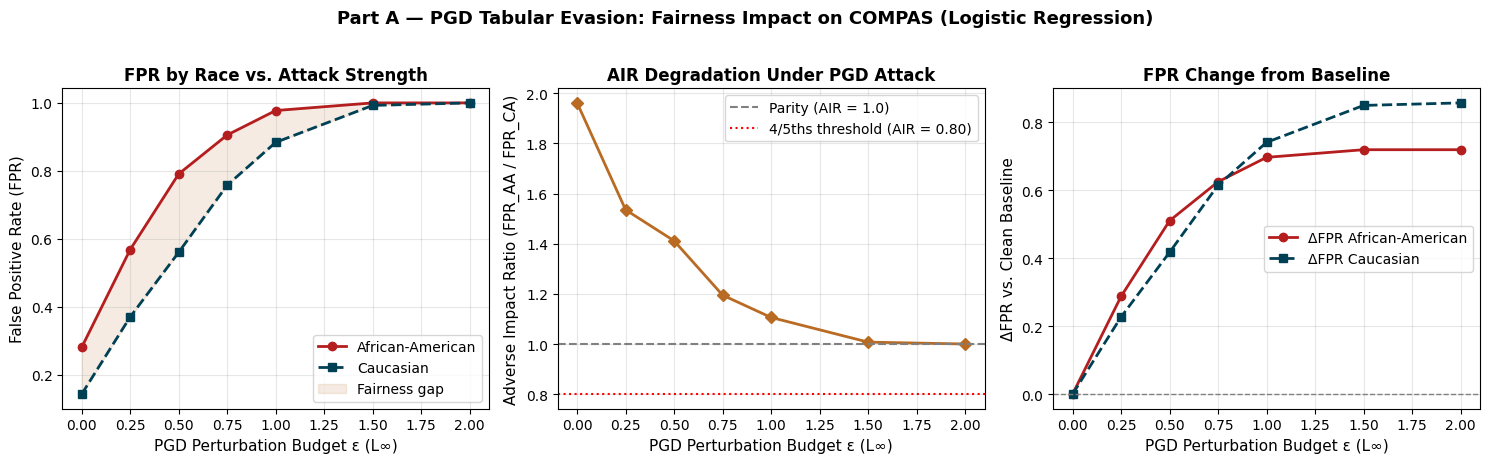

AIR does not fall below 0.80 within the tested epsilon range.


In [26]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [27]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

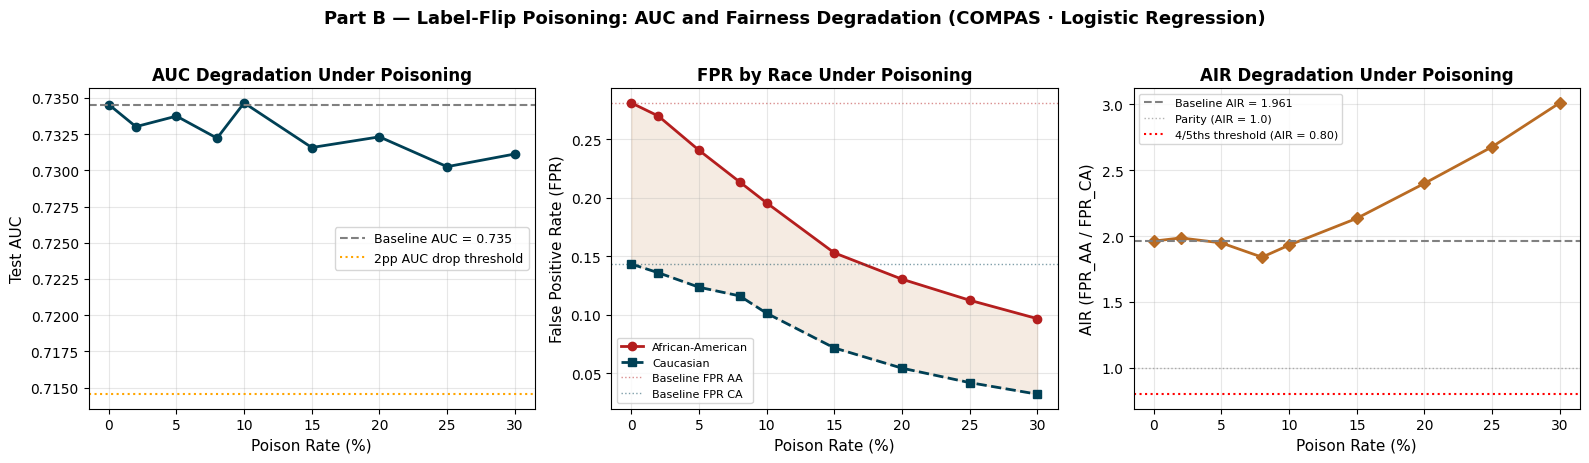

In [28]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [29]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

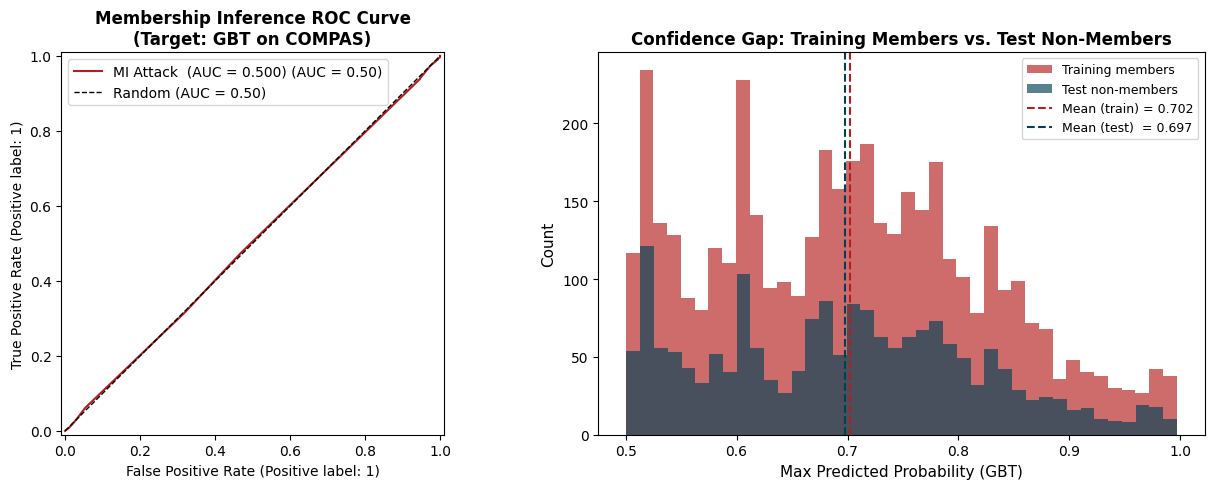

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [30]:
# ── Cell 8: Membership Inference ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

# Individual Assignment
# DNSC 6330 Individual Homework 5 report has the answers and interpretations

---
## (1) PGD Evasion Audit


In [31]:
def pgd_tabular_gbt(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=20):
    """Score-based PGD for GBT — no access to weights needed."""
    X_adv = X_scaled.copy()
    delta = 1e-3
    for _ in range(n_iter):
        scores_base = model.predict_proba(X_adv)[:, 1]
        grad = np.zeros_like(X_adv)
        for j in range(X_adv.shape[1]):
            X_plus = X_adv.copy()
            X_plus[:, j] += delta
            grad[:, j] = (model.predict_proba(X_plus)[:, 1] - scores_base) / delta
        X_adv = X_adv + alpha * np.sign(grad)
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv

hw_epsilons = [0.0, 0.25, 0.5, 1.0, 2.0]

# GBT baseline
fpr_gbt_base = fpr_by_group(y_te, pred_gbt_clean, r_te)
BASELINE_GBT_AA = fpr_gbt_base.get('African-American', np.nan)
BASELINE_GBT_CA = fpr_gbt_base.get('Caucasian', np.nan)

gbt_pgd_records = []
for eps in hw_epsilons:
    X_adv = Xs_te if eps == 0.0 else pgd_tabular_gbt(gbt, Xs_te, epsilon=eps)
    pred_adv = (gbt.predict_proba(X_adv)[:, 1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)
    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian', np.nan)
    gbt_pgd_records.append({'epsilon': eps, 'FPR_AA': aa, 'FPR_CA': ca, 'AIR': air(ca, aa)})

df_pgd_gbt = pd.DataFrame(gbt_pgd_records)

# LR subset from df_pgd
df_pgd_lr_hw = df_pgd[df_pgd['epsilon'].isin(hw_epsilons)].reset_index(drop=True)

print("LR — PGD results:")
print(df_pgd_lr_hw[['epsilon','FPR_AA','FPR_CA','AIR']].round(3).to_string(index=False))
print("\nGBT — PGD results:")
print(df_pgd_gbt[['epsilon','FPR_AA','FPR_CA','AIR']].round(3).to_string(index=False))


LR — PGD results:
 epsilon  FPR_AA  FPR_CA   AIR
    0.00   0.281   0.143 1.961
    0.25   0.569   0.370 1.535
    0.50   0.791   0.560 1.411
    1.00   0.978   0.884 1.106
    2.00   1.000   1.000 1.000

GBT — PGD results:
 epsilon  FPR_AA  FPR_CA   AIR
    0.00   0.317   0.178 1.782
    0.25   0.317   0.178 1.782
    0.50   0.317   0.178 1.782
    1.00   0.317   0.178 1.782
    2.00   0.317   0.178 1.782


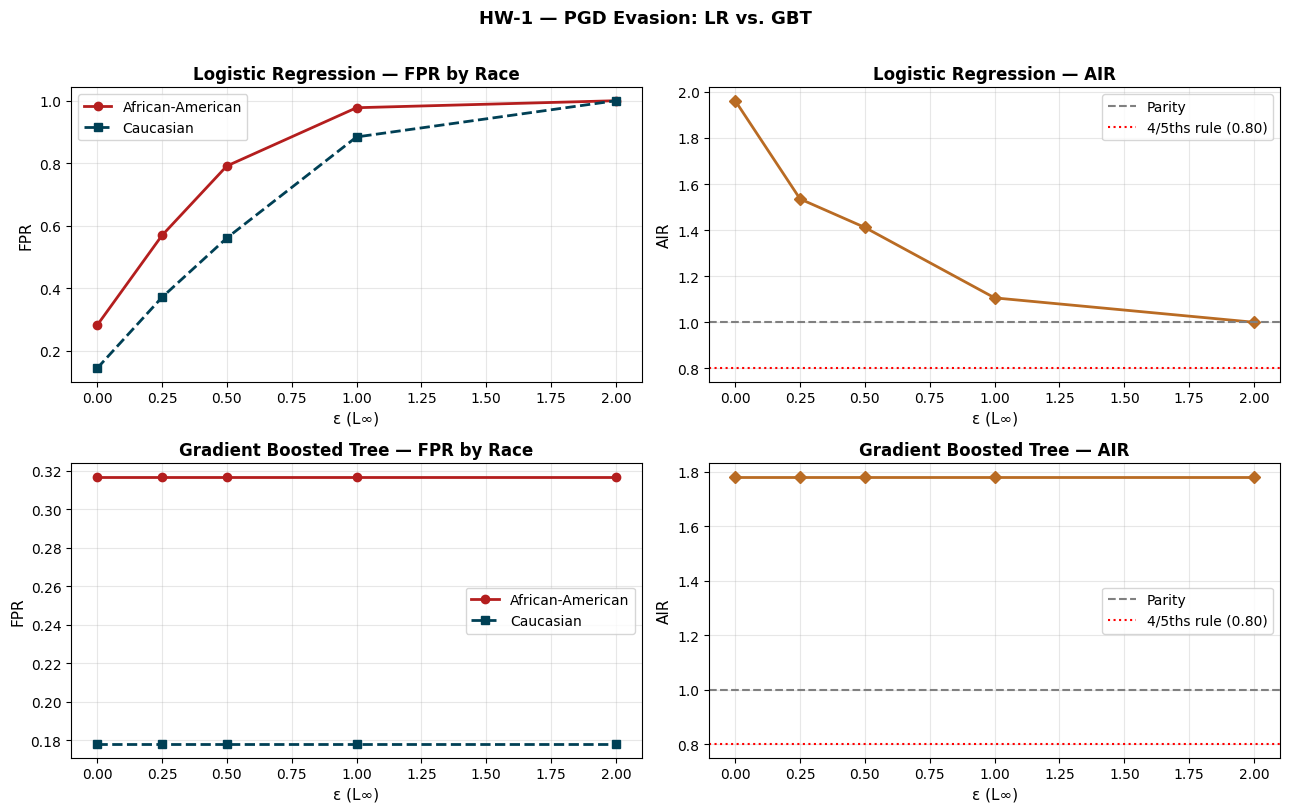

In [32]:
# ── HW-1: Plot LR vs GBT side by side ────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (name, df_, baa, bca) in enumerate([
    ('Logistic Regression',   df_pgd_lr_hw, BASELINE_AA,     BASELINE_CA),
    ('Gradient Boosted Tree', df_pgd_gbt,   BASELINE_GBT_AA, BASELINE_GBT_CA),
]):
    ax = axes[row, 0]
    ax.plot(df_['epsilon'], df_['FPR_AA'], 'o-', color='#B41E1E', lw=2, label='African-American')
    ax.plot(df_['epsilon'], df_['FPR_CA'], 's--', color='#004055', lw=2, label='Caucasian')
    ax.set_xlabel('ε (L∞)', fontsize=11); ax.set_ylabel('FPR', fontsize=11)
    ax.set_title(f'{name} — FPR by Race', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[row, 1]
    ax.plot(df_['epsilon'], df_['AIR'], 'D-', color='#B96B23', lw=2)
    ax.axhline(1.0, color='gray', ls='--', lw=1.5, label='Parity')
    ax.axhline(0.8, color='red',  ls=':',  lw=1.5, label='4/5ths rule (0.80)')
    ax.set_xlabel('ε (L∞)', fontsize=11); ax.set_ylabel('AIR', fontsize=11)
    ax.set_title(f'{name} — AIR', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('HW-1 — PGD Evasion: LR vs. GBT', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## (2) Poisoning Loop with Fairness Monitoring

In [33]:
def compute_psi(ref_scores, cur_scores, buckets=10):
    bp = np.percentile(ref_scores, np.linspace(0, 100, buckets+1))
    bp[0] -= 1e-9; bp[-1] += 1e-9
    ec = np.histogram(ref_scores, bp)[0] / len(ref_scores)
    ac = np.histogram(cur_scores, bp)[0] / len(cur_scores)
    ec = np.where(ec==0, 1e-6, ec); ac = np.where(ac==0, 1e-6, ac)
    return float(np.sum((ac - ec) * np.log(ac / ec)))

scores_clean = lr.predict_proba(Xs_te)[:, 1]

# Caucasian-targeted sweep
records_ca, psi_aa = [], []

for rate in poison_rates:
    # CA target
    y_p, n = poison_label_flip(y_tr, r_tr, poison_rate=rate, target_race='Caucasian')
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_p)
    pred_p = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)
    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian', np.nan)
    psi_ca = compute_psi(scores_clean, lr_p.predict_proba(Xs_te)[:, 1])
    records_ca.append({'poison_rate': rate, 'n_flipped': n, 'AUC': auc_p,
        'delta_AUC': auc_p - baseline_auc, 'FPR_AA': aa, 'FPR_CA': ca,
        'AIR': air(ca, aa), 'PSI': psi_ca})

    # PSI for AA-targeted (refit)
    y_p2, _ = poison_label_flip(y_tr, r_tr, poison_rate=rate, target_race='African-American')
    lr_p2 = LogisticRegression(max_iter=1000).fit(Xs_tr, y_p2)
    psi_aa.append(compute_psi(scores_clean, lr_p2.predict_proba(Xs_te)[:, 1]))

df_poison_ca = pd.DataFrame(records_ca)
df_poison['PSI'] = psi_aa   # add PSI to existing AA df from Cell 5

print("Caucasian-targeted poisoning:")
print(df_poison_ca[['poison_rate','AUC','delta_AUC','FPR_AA','FPR_CA','AIR','PSI']].round(3).to_string(index=False))


Caucasian-targeted poisoning:
 poison_rate   AUC  delta_AUC  FPR_AA  FPR_CA   AIR   PSI
        0.00 0.735      0.000   0.281   0.143 1.961 0.000
        0.02 0.734     -0.001   0.274   0.141 1.948 0.002
        0.05 0.734     -0.000   0.267   0.131 2.043 0.005
        0.08 0.734     -0.000   0.245   0.126 1.945 0.007
        0.10 0.735      0.001   0.243   0.123 1.966 0.015
        0.15 0.733     -0.002   0.231   0.121 1.913 0.020
        0.20 0.733     -0.001   0.209   0.111 1.881 0.048
        0.25 0.733     -0.001   0.191   0.104 1.842 0.055
        0.30 0.732     -0.003   0.182   0.094 1.940 0.078


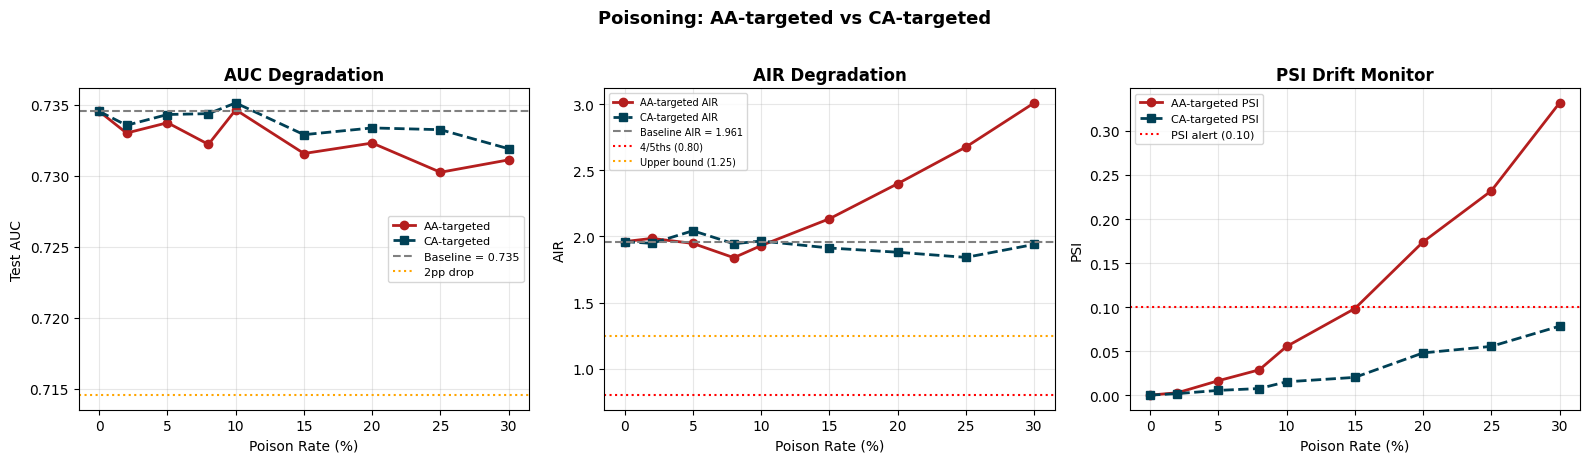

── (b) Stealth zone: ΔAUC ≤ 2pp AND AIR outside [0.80, 1.25] ──
  AA-targeted: starts at 0%  AIR=1.961  ΔAUC=+0.000
  CA-targeted: starts at 0%  AIR=1.961  ΔAUC=+0.000

── (c) PSI detection ──
  AA-targeted: PSI ≥ 0.10 first at 20% — but stealth zone starts earlier
  CA-targeted: PSI never reaches 0.10 — attack undetected by drift monitor


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x = df_poison['poison_rate'] * 100

ax = axes[0]
ax.plot(x, df_poison['AUC'],    'o-',  color='#B41E1E', lw=2, label='AA-targeted')
ax.plot(x, df_poison_ca['AUC'], 's--', color='#004055', lw=2, label='CA-targeted')
ax.axhline(baseline_auc,       color='gray',   ls='--', lw=1.5, label=f'Baseline = {baseline_auc:.3f}')
ax.axhline(baseline_auc-0.02,  color='orange', ls=':',  lw=1.5, label='2pp drop')
ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel('Test AUC')
ax.set_title('AUC Degradation', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(x, df_poison['AIR'],    'o-',  color='#B41E1E', lw=2, label='AA-targeted AIR')
ax.plot(x, df_poison_ca['AIR'], 's--', color='#004055', lw=2, label='CA-targeted AIR')
ax.axhline(BASELINE_AIR, color='gray',   ls='--', lw=1.5, label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(0.8,          color='red',    ls=':',  lw=1.5, label='4/5ths (0.80)')
ax.axhline(1.25,         color='orange', ls=':',  lw=1.5, label='Upper bound (1.25)')
ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel('AIR')
ax.set_title('AIR Degradation', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(x, df_poison['PSI'],    'o-',  color='#B41E1E', lw=2, label='AA-targeted PSI')
ax.plot(x, df_poison_ca['PSI'], 's--', color='#004055', lw=2, label='CA-targeted PSI')
ax.axhline(0.10, color='red', ls=':', lw=1.5, label='PSI alert (0.10)')
ax.set_xlabel('Poison Rate (%)'); ax.set_ylabel('PSI')
ax.set_title('PSI Drift Monitor', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Poisoning: AA-targeted vs CA-targeted', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# (b) Stealth zone
print("── (b) Stealth zone: ΔAUC ≤ 2pp AND AIR outside [0.80, 1.25] ──")
for name, df_ in [('AA-targeted', df_poison), ('CA-targeted', df_poison_ca)]:
    s = df_[(df_['delta_AUC'] >= -0.02) & ((df_['AIR'] < 0.80) | (df_['AIR'] > 1.25))]
    if len(s):
        r = s.iloc[0]
        print(f"  {name}: starts at {r['poison_rate']:.0%}  AIR={r['AIR']:.3f}  ΔAUC={r['delta_AUC']:+.3f}")
    else:
        print(f"  {name}: no stealth zone found")

# (c) PSI detection
print("\n── (c) PSI detection ──")
for name, df_ in [('AA-targeted', df_poison), ('CA-targeted', df_poison_ca)]:
    flagged = df_[df_['PSI'] >= 0.10]
    if len(flagged):
        print(f"  {name}: PSI ≥ 0.10 first at {flagged.iloc[0]['poison_rate']:.0%} — but stealth zone starts earlier")
    else:
        print(f"  {name}: PSI never reaches 0.10 — attack undetected by drift monitor")


**AUC Degradation:** Both attacks leave overall model accuracy nearly intact. The AA-targeted attack shows slightly more volatility (dipping to ~0.730 at 15–25%), while the CA-targeted attack is even more stable, hovering within ~0.003 of the 0.735 baseline throughout. Neither variant crosses the 2pp drop threshold (0.715).

**AIR Degradation:** This is where the attacks diverge sharply. The AA-targeted attack drives AIR from the baseline of 1.961 steeply upward — reaching ~3.0 at 30% — meaning African-Americans are increasingly denied at a much higher rate relative to Caucasians. The CA-targeted attack keeps AIR tightly bounded near 1.9–2.0 across all poison rates, never approaching either boundary of [0.80, 1.25].

---
## (3) Membership Inference Depth


In [35]:
conf_lr_train = lr.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_lr_test  = lr.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_all_lr = np.concatenate([
    meta_clf.predict_proba(conf_lr_train)[:, 1],
    meta_clf.predict_proba(conf_lr_test)[:, 1]
])
mi_labels = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
mi_auc_lr = roc_auc_score(mi_labels, mi_all_lr)

lr_train_auc = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:, 1])
lr_test_auc  = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])
gen_gap_lr   = lr_train_auc - lr_test_auc

print("MI AUC vs. Generalization Gap:")
print(f"  LR   Gen Gap: {gen_gap_lr:+.3f}   MI AUC: {mi_auc_lr:.3f}")
print(f"  GBT  Gen Gap: {gen_gap:+.3f}   MI AUC: {mi_auc:.3f}")

C_vals = [0.01, 0.1, 1.0, 10.0]
c_records = []

for C in C_vals:
    lr_c = LogisticRegression(C=C, max_iter=1000).fit(Xs_tr, y_tr)
    tr_a = roc_auc_score(y_tr, lr_c.predict_proba(Xs_tr)[:, 1])
    te_a = roc_auc_score(y_te, lr_c.predict_proba(Xs_te)[:, 1])
    mi_c = roc_auc_score(mi_labels, np.concatenate([
        meta_clf.predict_proba(lr_c.predict_proba(Xs_tr).max(axis=1).reshape(-1,1))[:,1],
        meta_clf.predict_proba(lr_c.predict_proba(Xs_te).max(axis=1).reshape(-1,1))[:,1]
    ]))
    c_records.append({'C': C, 'train_auc': tr_a, 'test_auc': te_a, 'mi_auc': mi_c})
    print(f"  C={C:5.2f}  Train AUC={tr_a:.3f}  Test AUC={te_a:.3f}  MI AUC={mi_c:.3f}")

df_c = pd.DataFrame(c_records)


MI AUC vs. Generalization Gap:
  LR   Gen Gap: -0.008   MI AUC: 0.494
  GBT  Gen Gap: +0.080   MI AUC: 0.500
  C= 0.01  Train AUC=0.726  Test AUC=0.732  MI AUC=0.493
  C= 0.10  Train AUC=0.727  Test AUC=0.734  MI AUC=0.495
  C= 1.00  Train AUC=0.727  Test AUC=0.735  MI AUC=0.494
  C=10.00  Train AUC=0.727  Test AUC=0.735  MI AUC=0.495


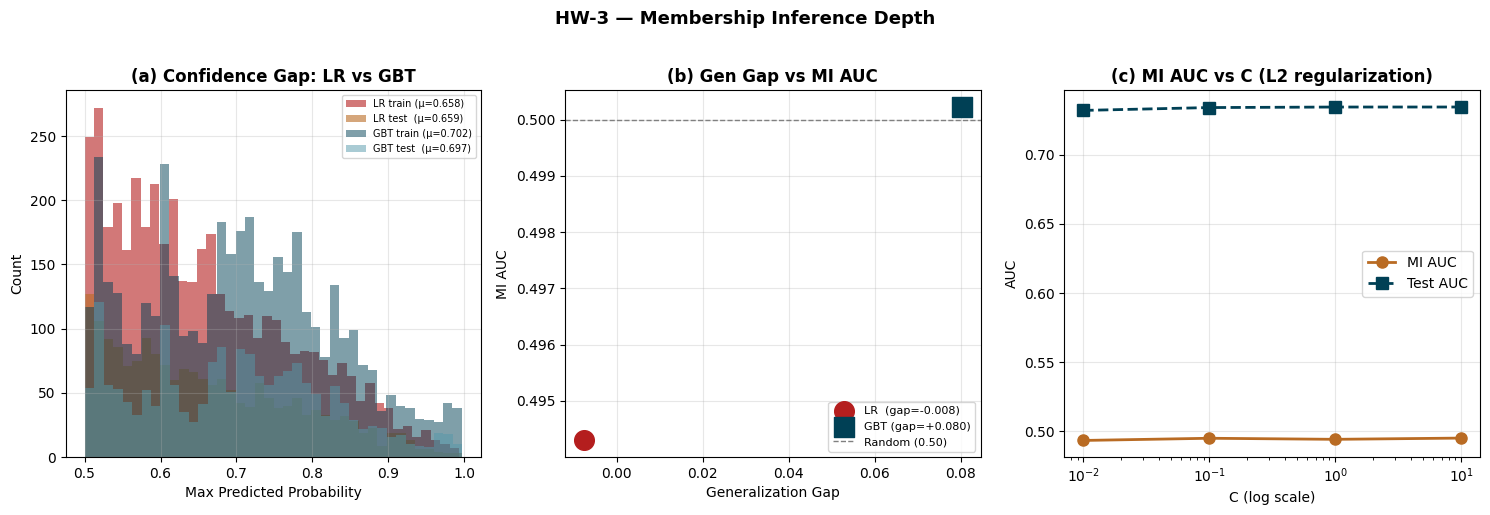

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Confidence gap histograms — LR vs GBT
ax = axes[0]
ax.hist(conf_lr_train.ravel(),     bins=40, alpha=0.6, color='#B41E1E', label=f'LR train (μ={conf_lr_train.mean():.3f})')
ax.hist(conf_lr_test.ravel(),      bins=40, alpha=0.6, color='#B96B23', label=f'LR test  (μ={conf_lr_test.mean():.3f})')
ax.hist(conf_target_train.ravel(), bins=40, alpha=0.5, color='#004055', label=f'GBT train (μ={conf_target_train.mean():.3f})')
ax.hist(conf_target_test.ravel(),  bins=40, alpha=0.5, color='#5599AA', label=f'GBT test  (μ={conf_target_test.mean():.3f})')
ax.set_xlabel('Max Predicted Probability'); ax.set_ylabel('Count')
ax.set_title('(a) Confidence Gap: LR vs GBT', fontweight='bold')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# (b) Gen gap vs MI AUC
ax = axes[1]
ax.scatter([gen_gap_lr], [mi_auc_lr], s=200, color='#B41E1E', zorder=5, label=f'LR  (gap={gen_gap_lr:+.3f})')
ax.scatter([gen_gap],    [mi_auc],    s=200, color='#004055', marker='s', zorder=5, label=f'GBT (gap={gen_gap:+.3f})')
ax.axhline(0.5, color='gray', ls='--', lw=1, label='Random (0.50)')
ax.set_xlabel('Generalization Gap'); ax.set_ylabel('MI AUC')
ax.set_title('(b) Gen Gap vs MI AUC', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (c) MI AUC vs C
ax = axes[2]
ax.plot(df_c['C'], df_c['mi_auc'],   'o-', color='#B96B23', lw=2, ms=8, label='MI AUC')
ax.plot(df_c['C'], df_c['test_auc'], 's--', color='#004055', lw=2, ms=8, label='Test AUC')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('AUC')
ax.set_title('(c) MI AUC vs C (L2 regularization)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('HW-3 — Membership Inference Depth', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
